## Plotting
- To use plotting we will be transforming all the needed features data into `data` data frame 

In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import pickle

In [2]:
path = "/kaggle/input/datasets/ashura369/sentiment-df-1/df_1.kl"
with open(path, 'rb') as file:
    data = pickle.load(file)

In [3]:
data.sample(6)

,id,name,date,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
14048,569673900805783552,PhilAuxier,2015-02-22,Sunday,17,Central_Time,American,anxious to see how you all care for customers ...,Cancelled Flight,1.0000,0,negative
4290,567731810910498816,BhutanOrient,2015-02-17,Tuesday,9,Pacific_Time,United,+what took me aback was the response by the fl...,Flight Attendant Complaints,0.6812,0,negative
2508,569153669867945984,smonnat,2015-02-21,Saturday,7,Eastern_Time,United,officially has the most inefficient boarding p...,Flight Attendant Complaints,0.3551,1,negative
9491,569908805724712961,juliebartz,2015-02-23,Monday,9,Central_Time,US_Airways,how do you get your aa frequent flyer number t...,Customer Service Issue,0.3526,0,negative
10344,569360552272769024,TheSanjR,2015-02-21,Saturday,20,Eastern_Time,US_Airways,stranded at BWI after two diversions. No cust ...,Customer Service Issue,1.0000,0,negative
5513,568929754151145472,KathyCoonan,2015-02-20,Friday,16,Eastern_Time,Southwest,Feels like a good day to fly!! Thanks for the...,Customer Service Issue,0.0000,0,positive


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Shows all columns
pd.set_option('display.max_columns', None)

# Shows all rows (be careful if the data has 10,000+ rows)
pd.set_option('display.max_rows', None)

In [6]:
pd.crosstab(index=data['airlines'], columns=data['sentiment'])

sentiment,negative,neutral,positive
airlines,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US_Airways,2263,381,269
United,2633,697,492
Virgin_America,181,171,152


In [7]:
pd.crosstab(index=data['airlines'], columns=data['sentiment'], margins=True, margins_name='SUM')   # REMEMBER : by default when using margins in crosstab, bydefault it takes sum of the values

sentiment,negative,neutral,positive,SUM
airlines,,,,
American,1960,463,336,2759
Delta,955,723,544,2222
Southwest,1186,664,570,2420
US_Airways,2263,381,269,2913
United,2633,697,492,3822
Virgin_America,181,171,152,504
SUM,9178,3099,2363,14640


In [8]:
data.pivot_table(index='airlines', columns='sentiment', aggfunc='count')

id                      name                      date  \
sentiment      negative neutral positive negative neutral positive negative   
airlines                                                                      
American           1960     463      336     1960     463      336     1960   
Delta               955     723      544      955     723      544      955   
Southwest          1186     664      570     1186     664      570     1186   
US_Airways         2263     381      269     2263     381      269     2263   
United             2633     697      492     2633     697      492     2633   
Virgin_America      181     171      152      181     171      152      181   

                                day_name                      hour          \
sentiment      neutral positive negative neutral positive negative neutral   
airlines                                                                     
American           463      336     1960     463      336     1960     463   
Delta              723      544      955     723      544      955     723   
Southwest          664      570     1186     664      570     1186     664   
US_Airways         381      269     2263     381      269     2263     381   
United             697      492     2633     697      492     2633     697   
Virgin_America     171      152      181     171      152      181     171   

                        timezone                  feedback                   \
sentiment      positive negative neutral positive negative neutral positive   
airlines                                                                      
American            336     1960     463      336     1960     463      336   
Delta               544      955     723      544      955     723      544   
Southwest           570     1186     664      570     1186     664      570   
US_Airways          269     2263     381      269     2263     381      269   
United              492     2633     697      492     2633     697      492   
Virgin_America      152      181     171      152      181     171      152   

                 reason                  reason_confidence                   \
sentiment      negative neutral positive          negative neutral positive   
airlines                                                                      
American           1960     463      336              1960     463      336   
Delta               955     723      544               955     723      544   
Southwest          1186     664      570              1186     664      570   
US_Airways         2263     381      269              2263     381      269   
United             2633     697      492              2633     697      492   
Virgin_America      181     171      152               181     171      152   

               retweets                   
sentiment      negative neutral positive  
airlines                                  
American           1960     463      336  
Delta               955     723      544  
Southwest          1186     664      570  
US_Airways         2263     381      269  
United             2633     697      492  
Virgin_America      181     171      152

In [9]:
data.pivot_table(
    index='reason',
    columns= 'sentiment',
    aggfunc='count'
)

id                      name          \
sentiment                   negative neutral positive negative neutral   
reason                                                                   
Bad Flight                       580     125      103      580     125   
Can't Tell                      1190     640      393     1190     640   
Cancelled Flight                 847     107       97      847     107   
Customer Service Issue          2910    1352     1025     2910    1352   
Damaged Luggage                   74       2     <NA>       74       2   
Flight Attendant Complaints      481      74       47      481      74   
Flight Booking Problems          529     102       55      529     102   
Late Flight                     1665     604      550     1665     604   
Lost Luggage                     724      93       83      724      93   
longlines                        178    <NA>       10      178    <NA>   

                                         date                  day_name  \
sentiment                   positive negative neutral positive negative   
reason                                                                    
Bad Flight                       103      580     125      103      580   
Can't Tell                       393     1190     640      393     1190   
Cancelled Flight                  97      847     107       97      847   
Customer Service Issue          1025     2910    1352     1025     2910   
Damaged Luggage                 <NA>       74       2     <NA>       74   
Flight Attendant Complaints       47      481      74       47      481   
Flight Booking Problems           55      529     102       55      529   
Late Flight                      550     1665     604      550     1665   
Lost Luggage                      83      724      93       83      724   
longlines                         10      178    <NA>       10      178   

                                                 hour                   \
sentiment                   neutral positive negative neutral positive   
reason                                                                   
Bad Flight                      125      103      580     125      103   
Can't Tell                      640      393     1190     640      393   
Cancelled Flight                107       97      847     107       97   
Customer Service Issue         1352     1025     2910    1352     1025   
Damaged Luggage                   2     <NA>       74       2     <NA>   
Flight Attendant Complaints      74       47      481      74       47   
Flight Booking Problems         102       55      529     102       55   
Late Flight                     604      550     1665     604      550   
Lost Luggage                     93       83      724      93       83   
longlines                      <NA>       10      178    <NA>       10   

                            timezone                  airlines          \
sentiment                   negative neutral positive negative neutral   
reason                                                                   
Bad Flight                       580     125      103      580     125   
Can't Tell                      1190     640      393     1190     640   
Cancelled Flight                 847     107       97      847     107   
Customer Service Issue          2910    1352     1025     2910    1352   
Damaged Luggage                   74       2     <NA>       74       2   
Flight Attendant Complaints      481      74       47      481      74   
Flight Booking Problems          529     102       55      529     102   
Late Flight                     1665     604      550     1665     604   
Lost Luggage                     724      93       83      724      93   
longlines                        178    <NA>       10      178    <NA>   

                                     feedback                   \
sentiment                   positive negative neutral positive   
reason                               

<Axes: ylabel='Density'>

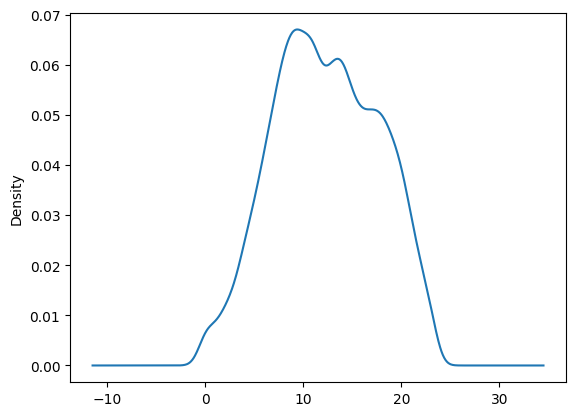

In [10]:
# kde plot for hour
data['hour'].plot(kind='kde')

<Axes: ylabel='Density'>

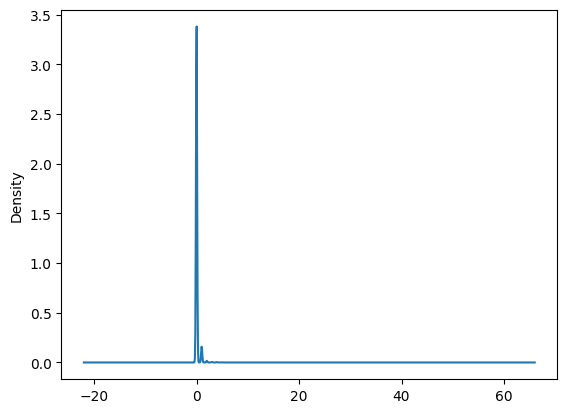

In [11]:
data['retweets'].plot(kind='kde')

<Axes: ylabel='Density'>

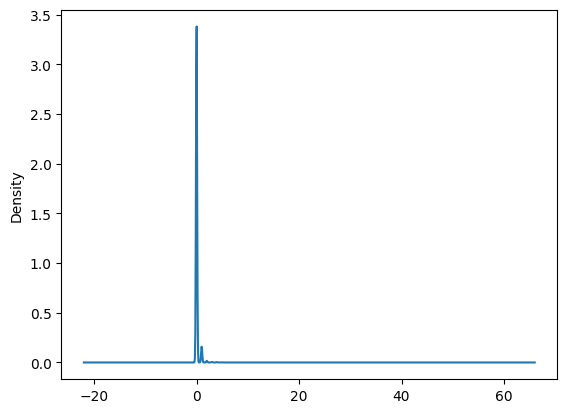

In [12]:
data['retweets'].plot(kind='density')

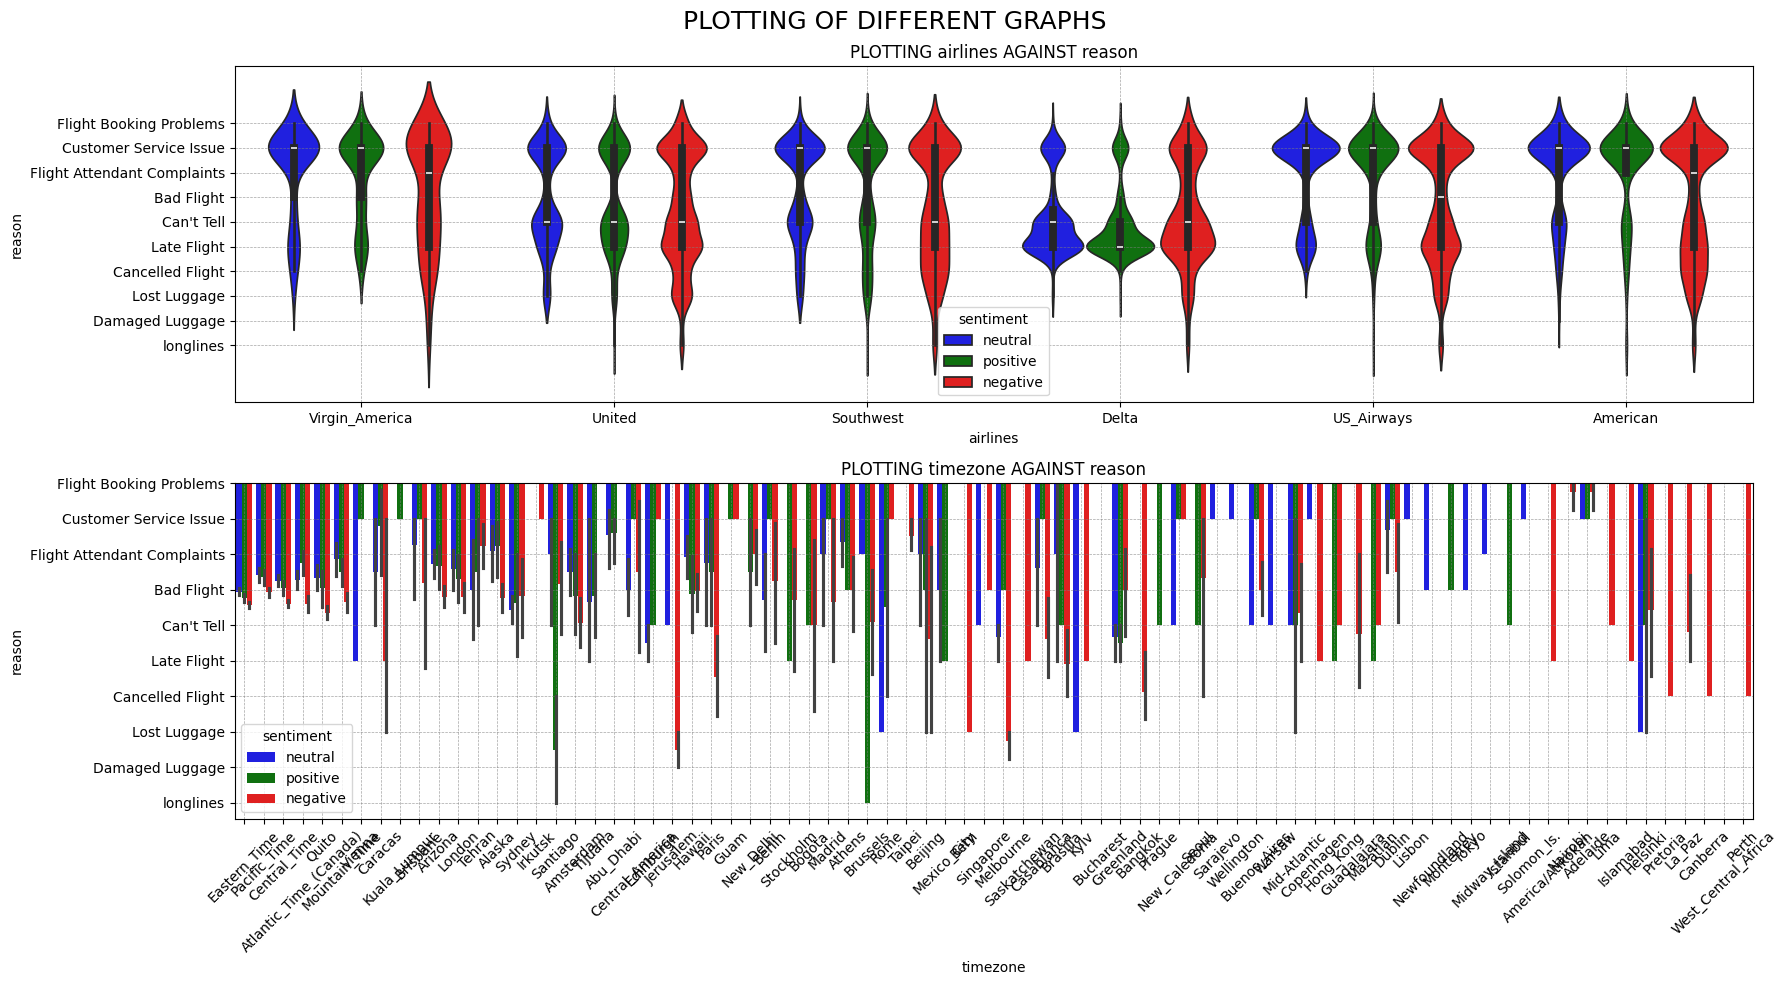

In [13]:
num_of_plots = 2
height_per_plot = 5

fig, axes = plt.subplots(num_of_plots, 1, figsize=(18, num_of_plots * height_per_plot))

# ---------------------------------------------------------------------------------
x='airlines'
y='reason'
colors = {'positive':'green','neutral':'blue','negative':'red'}
sns.violinplot(data, x=x, y=y, hue='sentiment', palette=colors, ax=axes[0])
axes[0].grid(True)
axes[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_title(f'PLOTTING {x} AGAINST {y}')
# ---------------------------------------------------------------------------------

x='timezone'
y='reason'
colors = {'positive':'green','neutral':'blue','negative':'red'}
sns.barplot(data, x=x, y=y, hue='sentiment', palette=colors, ax=axes[1])
axes[1].grid(True)
axes[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_title(f'PLOTTING {x} AGAINST {y}')
plt.xticks(rotation=45)


plt.suptitle('PLOTTING OF DIFFERENT GRAPHS', fontsize=18)
plt.tight_layout()
plt.show()

### EDA : Sentiment Drivers across Airlines and Timezones

#### 1. Violin Plot Analysis: Airlines vs. Reason
The top visualization utilizes a Violin Plot to map the density and distribution of tweet sentiments against specific reasons for various airlines. 

*   **Broad Spectrum of Negativity:** The red distributions (Negative Sentiment) stretch vertically across the entire Y-axis for all six airlines. This indicates that customer dissatisfaction is not isolated to a single failure point, but is driven by a wide spectrum of issues ranging from *Customer Service Issues* down to *Lost Luggage* and *Long Lines*. 
*   **Key Pain Points:** Airlines like **US Airways** and **American** show distinct density "bulges" (thicker areas) in their negative distributions near *Customer Service Issue* and *Late Flight*. This insight highlights that operational delays paired with poor communication are the primary drivers of brand damage.
*   **Positive/Neutral Clustering:** In contrast, the green (Positive) and blue (Neutral) distributions are more concentrated, suggesting that when customers are happy, it is rarely tied to a specific operational metric, but rather general satisfaction.

#### 2. Bar Chart Analysis: Timezone vs. Reason
The bottom visualization attempts to map sentiment and reasons across various user timezones.

*   **Volume Concentration:** The far-left side of the X-axis (which contains major US timezones like *Eastern*, *Pacific*, and *Central*) holds the vast majority of data points. Within these high-density timezones, Negative sentiment (red) heavily dominates almost every reason category.
*   **Data Sparsity Issues:** As the chart moves to the right into international or less populated timezones (e.g., *Tehran*, *Quito*), the data becomes extremely sparse. The severe fragmentation in this chart visually proves why high-cardinality categorical features (like raw timezones) must be aggressively cleaned, grouped, or dropped to prevent model overfitting during the Deep Learning phase.


### Deep Analysis: Brand Reputation Failure Points by Airline

Based on the density distribution of the Violin Plot (Airlines vs. Reason), we can perform an in-depth diagnosis of the specific operational failures driving negative sentiment (red distributions) for each individual airline. 

#### 1. Virgin America
*   **Primary Issue:** Compared to the legacy carriers, Virgin America's negative sentiment is uniquely distributed toward **Flight Booking Problems** and general **Customer Service Issues**. 
*   **Diagnosis:** Because Virgin America is often viewed as a premium/trendy airline, customers are highly sensitive to the initial digital experience (booking) and customer support interactions. There is less density around physical operational failures like *Lost Luggage*, suggesting their ground operations are relatively stable.

#### 2. United Airlines
*   **Primary Issue:** United shows a heavily elongated red distribution, meaning they suffer from a wide variety of complaints. However, the thickest density bulges occur at **Late Flight**, **Customer Service Issue**, and notably, **Lost Luggage**.
*   **Diagnosis:** United has a severe, multi-faceted operational problem. The strong presence of *Lost Luggage* and *Late Flight* indicates systemic failures in their physical logistics and ground crew operations, which then cascades into overwhelmed and poorly-received customer service.

#### 3. Southwest Airlines
*   **Primary Issue:** Southwest exhibits sharp spikes in negative sentiment specifically around **Cancelled Flight** and **Customer Service Issue**.
*   **Diagnosis:** Southwest operates on a unique point-to-point routing system (rather than a hub-and-spoke system). When weather or mechanical issues occur, flights are entirely cancelled rather than delayed. The data reflects this, showing that abrupt cancellations—and the subsequent struggle to get help from customer service—are the primary destroyers of Southwest's brand sentiment.

#### 4. Delta Air Lines
*   **Primary Issue:** Delta’s negative violin plot is heavily concentrated in the middle of the Y-axis, specifically bulging at **Late Flight** and **Customer Service Issue**.
*   **Diagnosis:** Delta appears to struggle significantly with on-time performance. However, unlike United, their distribution tapers off rapidly toward the bottom (fewer *Lost Luggage* or *Damaged Luggage* complaints). This indicates that while Delta struggles with flight scheduling, their baggage handling logistics are performing much better than their competitors.

#### 5. US Airways
*   **Primary Issue:** US Airways displays an incredibly massive, dense concentration of negative sentiment exclusively around **Customer Service Issue**, followed closely by **Late Flight**.
*   **Diagnosis:** The sheer thickness of the violin plot at *Customer Service Issue* points to a critical failure in human resources and customer relations. Even when flights are late, the overwhelming volume of complaints directed at the *service* itself suggests that passengers feel ignored or mistreated by staff during delays.

#### 6. American Airlines
*   **Primary Issue:** Similar to US Airways, American Airlines has a massive density spike at **Customer Service Issue**. However, American also shows significant secondary bulges at **Cancelled Flight** and **Late Flight**.
*   **Diagnosis:** American Airlines suffers from a "perfect storm" of negative drivers. They are experiencing high rates of operational disruptions (both delays and total cancellations), and their customer service infrastructure is completely failing to mitigate the anger of stranded passengers. This combination is highly toxic to brand reputation.

### Strategic Conclusion
Across almost all airlines, **Customer Service Issue** acts as a multiplier for negative sentiment. The data strongly suggests that passengers are somewhat forgiving of logistical issues (like delays or lost bags) *only if* the customer service response is excellent. Because the red density is thickest at customer service across the board, the industry as a whole is failing at damage control.


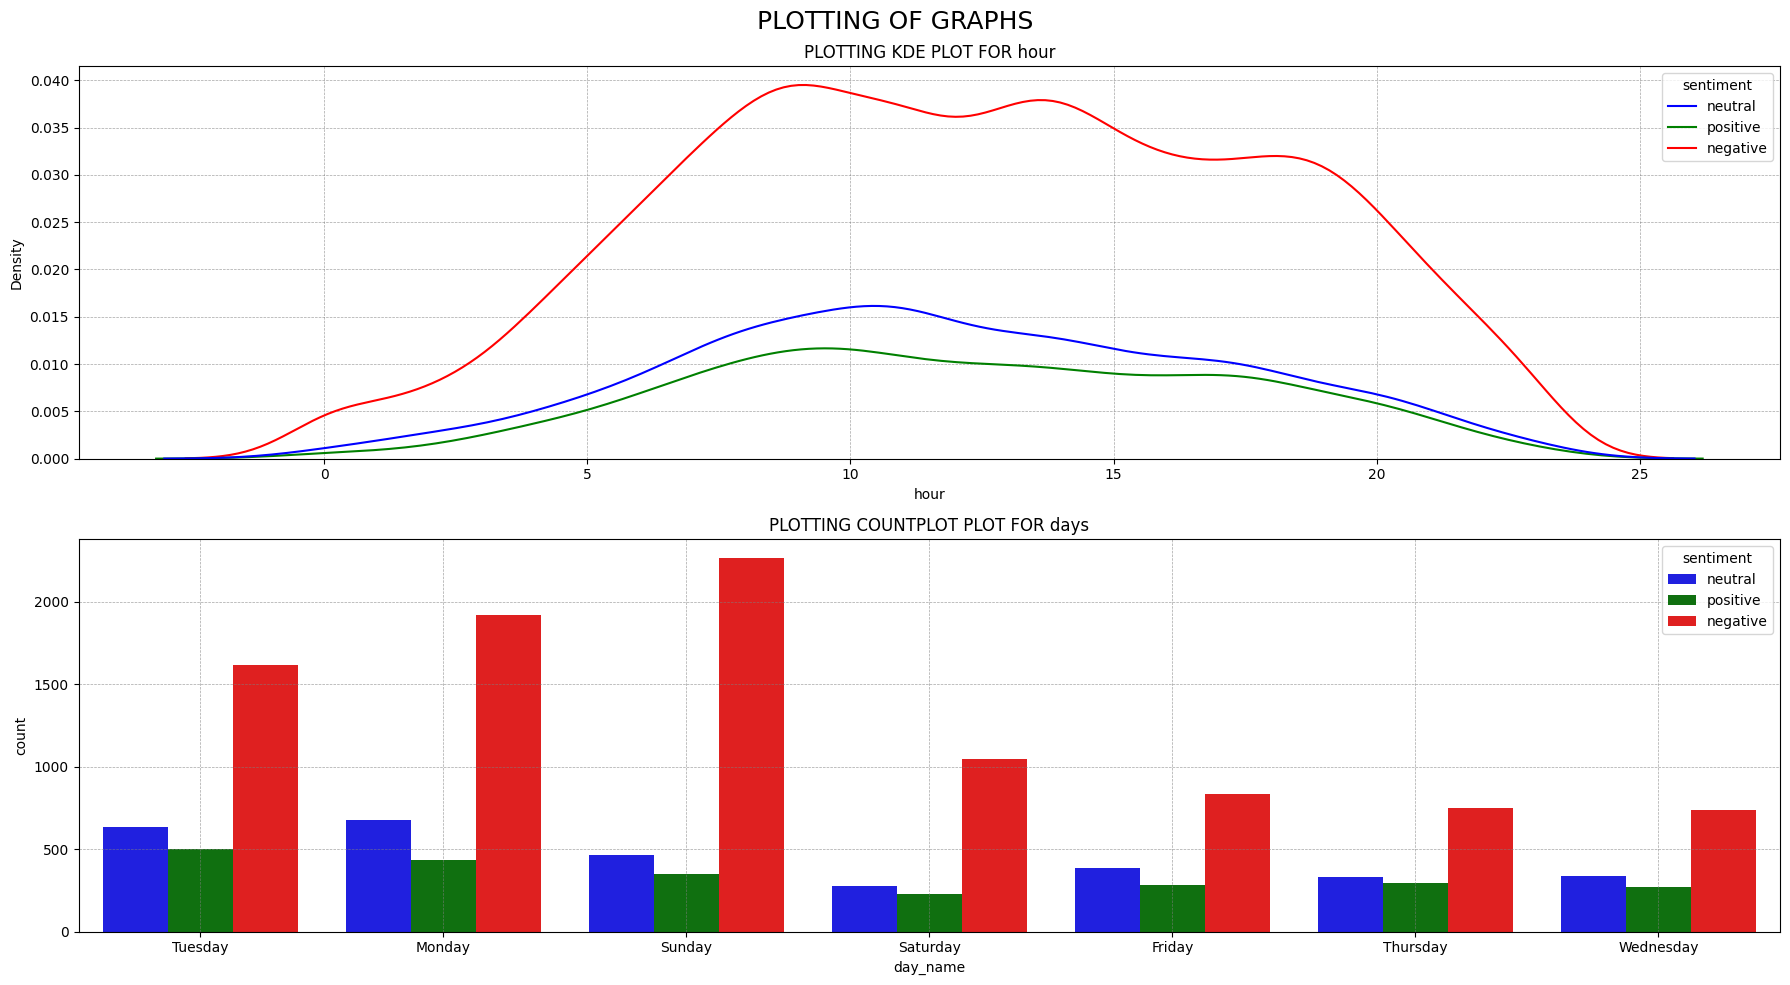

In [14]:
num_of_plots = 2
height_per_plot = 5

fig, axes = plt.subplots(num_of_plots, 1, figsize=(18, num_of_plots * height_per_plot))


x='hour'
colors = {'positive':'green','neutral':'blue','negative':'red'}
sns.kdeplot(data, x=x, hue='sentiment', palette=colors, ax=axes[0])
axes[0].grid(True)
axes[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_title(f'PLOTTING KDE PLOT FOR {x}')

# ---------------------------------------------------------------------------------

x_name='days'
colors = {'positive':'green','neutral':'blue','negative':'red'}
sns.countplot(data=data, x='day_name', hue='sentiment', palette=colors, ax=axes[1])
axes[1].grid(True)
axes[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_title(f'PLOTTING COUNTPLOT PLOT FOR {x_name}')


plt.suptitle('PLOTTING OF GRAPHS', fontsize=18)
plt.tight_layout()
plt.show()

### Report: Temporal and Daily Sentiment Drivers

#### 1. KDE Density Analysis: Sentiment vs. Hour of the Day (Top Graph)
The top visualization utilizes a Kernel Density Estimate (KDE) plot to map the volume distribution of tweets across a 24-hour cycle.

*   **Identical Temporal Behavior:** The most critical observation here is that the shape of the red (negative), blue (neutral), and green (positive) curves are virtually identical. They all begin rising around **05:00**, hit a prolonged plateau during standard waking hours **(08:00 to 18:00)**, and taper off sharply after **20:00**.
*   **Proportional Dominance (Common Norm):** Because the red curve is strictly higher than the blue and green curves at every single hour of the day, it visually confirms that **negative sentiment dominates the dataset**. 
*   **Analytical Conclusion:** The *time of day* does not trigger negative sentiment. Customers are **not significantly angrier in the morning versus the evening**. Instead, the volume of complaints perfectly mirrors general human wakefulness and standard travel hours. When passengers are awake and flying, they are complaining.

#### 2. Countplot Analysis: Sentiment vs. Day of the Week (Bottom Graph)
The bottom grouped bar chart provides a quantitative breakdown of sentiment volume across the seven days of the week. *(Note: Based on the data shape, the X-axis clusters represent Tuesday, Monday, Sunday, Saturday, Friday, Thursday, Wednesday from left to right).*

*   **The Sunday Crisis Peak:** The third cluster (Sunday) represents a massive operational breaking point. Negative sentiment **skyrockets past 2,200 tweets**, while **positive and neutral sentiments drop to near-weekly lows**. This indicates a severe **failure in handling the Sunday weekend-return travel rush**.
*   **The "Spillover" Effect (Monday & Tuesday):** The high volume of **negativity does not instantly resolve on Sunday night. It *spills over heavily into Monday (1,900 negative tweets) and Tuesday (1,600 negative tweets)**. This suggests that flights cancelled or delayed on Sunday create a multi-day customer service backlog.
*   **Mid-Week Stability:** The mid-week period (Wednesday through Saturday) shows a **drastic drop in overall tweet volume**. Negative complaints fall safely below the 1,000-tweet threshold. This is the only operational period where the airlines appear to **have adequate bandwidth to process the daily volume of passengers**.
*   **Strategic Recommendation:** Airlines are severely **understaffed on Sundays and Mondays**. By shifting ground crew and customer service representatives away from the relatively quiet mid-week and concentrating them on the Sunday-Monday crisis window, airlines could drastically mitigate the viral spread of negative brand sentiment.


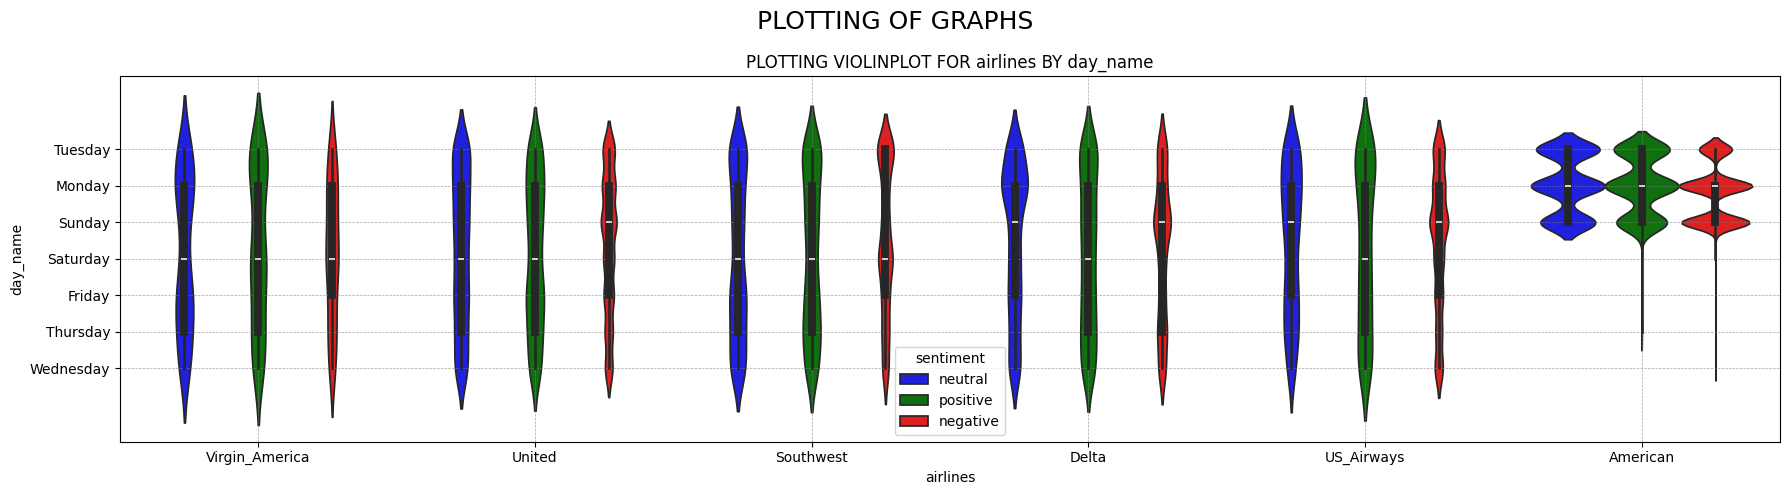

In [16]:
num_of_plots = 1
height_per_plot = 5

fig, axes = plt.subplots(num_of_plots, 1, figsize=(18, num_of_plots * height_per_plot))


x = 'airlines'
y = 'day_name' # Just the string name of the column!
colors = {'positive':'green','neutral':'blue','negative':'red'}
# Use a CountPlot to compare categories (Airlines vs Days)
sns.violinplot(x=data['airlines'], y=data['day_name'], hue=data['sentiment'], palette=colors, ax=axes)
axes.grid(True)
axes.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes.set_title(f'PLOTTING VIOLINPLOT FOR {x} BY {y}')


plt.suptitle('PLOTTING OF GRAPHS', fontsize=18)
plt.tight_layout()
plt.show()

### Airline Sentiment Density Across the Week

This Violin Plot visualizes the density and spread of customer sentiment for six major airlines across a 7-day operational timeline. By tracking the width of the "violins," we can identify exactly which days trigger the highest concentration of complaints or praise for each specific carrier.

#### General Industry Trend
Across almost all airlines, the **red distributions (Negative Sentiment) are noticeably thicker** than the blue (Neutral) and green (Positive) distributions. Furthermore, the thickest points of these red distributions consistently cluster around the **Friday to Monday** window, proving that weekend travel volume is the primary stress-test for the airline industry.

#### Airline-Specific Operational Analysis

*   **Virgin America (The Outlier):** Virgin America shows an incredibly smooth and uniform distribution across the entire week. Their positive, neutral, and negative sentiments do not have major "bulges" on specific days. This indicates a highly **consistent operational baseline** where service quality does not drastically degrade during the weekend rush.
*   **United & Southwest:** Both of these carriers show a noticeable "pinching" effect during the mid-week (Wednesday/Thursday), where complaints are lower. However, their negative sentiment (red) heavily balloons outward over **Saturday, Sunday, and Monday**. This indicates a failure to scale their customer service bandwidth to meet weekend demand.
*   **Delta Air Lines:** Delta exhibits one of the clearest temporal trends. Their negative sentiment distribution is extremely thin on Tuesday and Wednesday, but it swells into a massive bulge precisely on **Friday, Saturday, and Sunday**. This highlights that Delta's operational struggles are deeply and almost exclusively tied to the immediate weekend departure window.
*   **US Airways:** Similar to Delta, US Airways shows an aggressive concentration of negative sentiment starting on Saturday, peaking on **Sunday**, and trailing heavily into Monday. Their inability to process the Sunday return-flight rush creates a massive backlog of angry customers that spills over into the standard workweek.
*   **American Airlines (The Anomaly):** American Airlines displays a highly irregular distribution, breaking into isolated "blobs" rather than a continuous curve. These massive concentrations of data exist exclusively on **Sunday, Monday, and Tuesday**, with virtually zero density shown during the mid-week. This indicates that American Airlines experienced a catastrophic, concentrated operational meltdown specifically over a Sunday-Tuesday period, drastically skewing their overall brand sentiment.


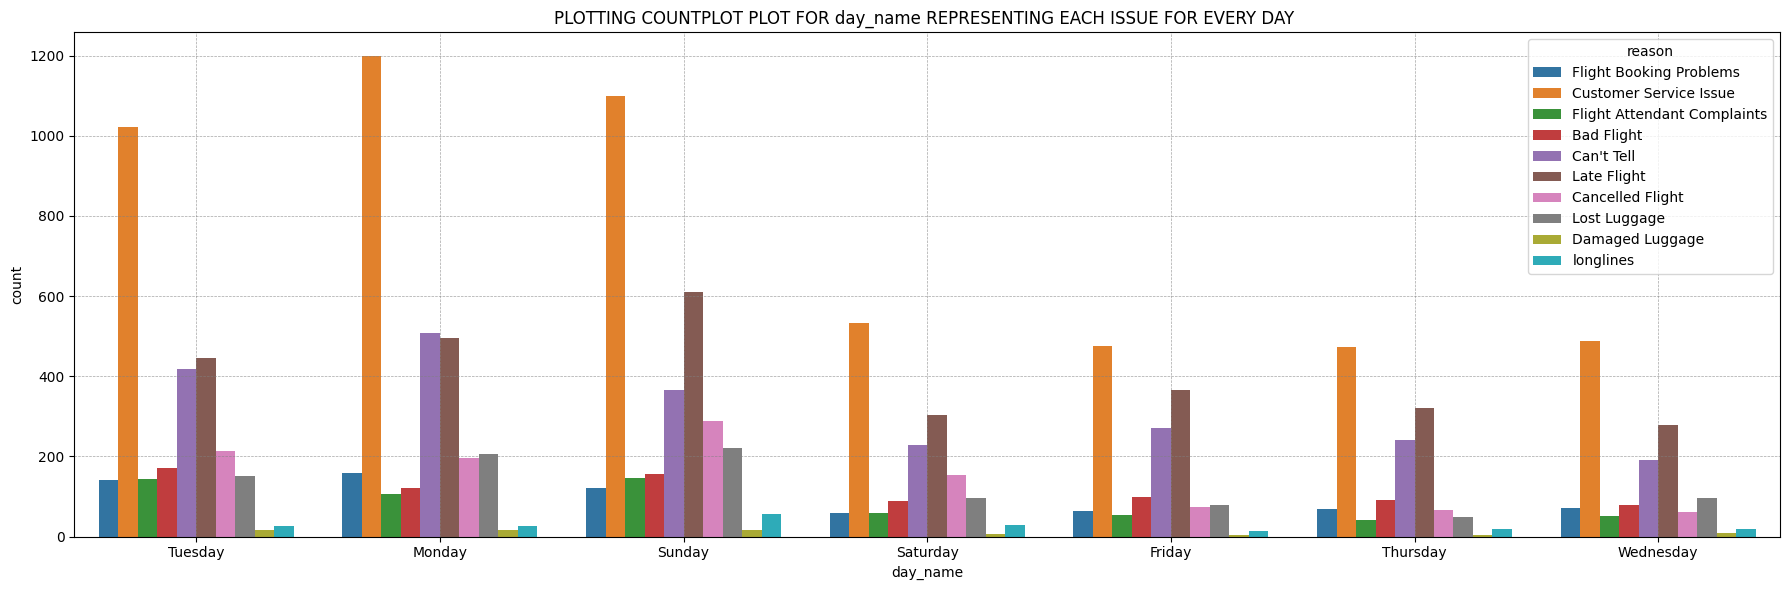

In [31]:
plt.figure(figsize=(18,6))

x_name='day_name'
sns.countplot(data=data, x='day_name', hue='reason')
plt.grid(True)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title(f'PLOTTING COUNTPLOT PLOT FOR {x_name} REPRESENTING EACH ISSUE FOR EVERY DAY ')

plt.tight_layout()
plt.show()

### Negative Reason Distribution by Day of the Week

This grouped bar chart provides a granular breakdown of the specific reasons driving negative sentiment across the seven days of the week.

#### 1. The Dominance of Customer Service Failures
The most striking observation is the absolute dominance of the **"Customer Service Issue"** category (orange bar). It is the leading cause of complaints on every single day of the week by a massive margin. It experiences a severe escalation starting on Sunday (1,100 complaints), peaking on Monday (>1,200 complaints), and remaining highly elevated on Tuesday (>1,000 complaints). During the mid-week, it drops to roughly 500 complaints per day but still **heavily outpaces all other categories**. This indicates a **systemic failure in the airline industry's customer support** infrastructure.

#### 2. Secondary Drivers: Operational Delays
The "Late Flight" category (brown bar) serves as the secondary driver of negative sentiment. It follows a similar trajectory to customer service issues, spiking highest on Sunday (>600 complaints) and Monday (500 complaints). This correlation strongly implies that **logistical failures (late flights) are the catalyst that drives passengers to seek out customer service, subsequently resulting in the massive spike in customer service complaints when the system becomes overwhelmed**.

#### 3. Weekend Specific Anomalies
*   **Cancelled Flights:** The "Cancelled Flight" category (pink bar) sees a distinct isolated **spike on Sunday** (approaching 300 complaints) and **Monday** (roughly 200). For the rest of the week, cancellations are a relatively minor issue. This reinforces the hypothesis that **weekend weather or scheduling cascades are the root cause of the early-week volume spikes**.
*   **Lost Luggage:** Similarly, "Lost Luggage" (grey bar) peaks strictly on **Sunday and Monday**, perfectly aligning with the surge in overall weekend travel volume.

#### 4. Baseline Metrics
Categories such as "Flight Attendant Complaints," "Bad Flight," "Damaged Luggage," and "Longlines" maintain a relatively flat, low-volume baseline throughout the entire week. This suggests that physical, in-flight experiences and airport ground operations (like security lines) are functioning acceptably, and the core brand damage is stemming almost entirely from scheduling logistics and digital/phone support staff.


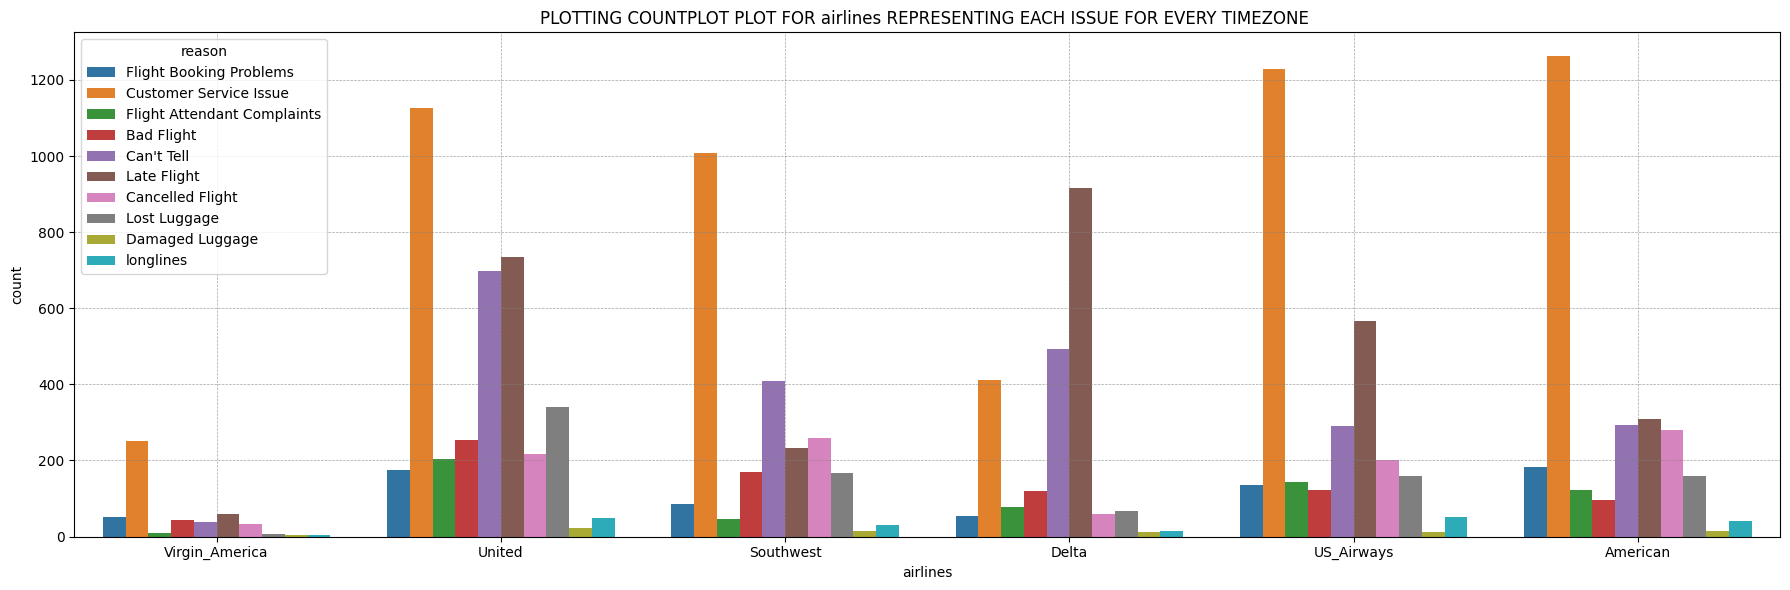

In [32]:
plt.figure(figsize=(18,6))

x_name='airlines'
sns.countplot(data=data, x='airlines', hue='reason')
plt.grid(True)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title(f'PLOTTING COUNTPLOT PLOT FOR {x_name} REPRESENTING EACH ISSUE FOR EVERY TIMEZONE ')

plt.tight_layout()
plt.show()

### Core Failure Points by Airline Brand

This grouped bar chart visualizes the precise breakdown of negative sentiment reasons attributed to each of the six major airlines. *(Note: While the chart title mentions timezones, the X-axis structurally plots Airlines versus Reason).*

#### 1. The Industry-Wide Customer Service Crisis
For four of the six major carriers—**United, Southwest, US Airways, and American**—the overwhelming primary cause of negative sentiment is "Customer Service Issue" (orange bar). 
*   **American Airlines and US Airways** perform the worst in this category, both breaching 1,200 complaints.
*   **United and Southwest** follow closely, both exceeding 1,000 complaints.
This visually confirms that while logistical issues (like delays) initiate the customer journey, the failure of the customer service infrastructure to resolve these issues is the primary destroyer of brand reputation for legacy carriers.

#### 2. The Delta Air Lines Anomaly
**Delta Air Lines** is the most striking outlier in the entire dataset. It is the *only* airline where "Customer Service Issue" is not the leading complaint. 
*   Delta’s primary failure is **"Late Flight"** (brown bar), which towers over 900 complaints. 
*   However, Delta's "Customer Service Issue" volume is drastically lower (around 400 complaints) compared to its competitors. 
*   **Strategic Insight:** This indicates that while Delta suffers from severe scheduling and on-time performance issues, their customer support teams are significantly more effective at de-escalating angry passengers compared to American or United. 

#### 3. Airline-Specific Logistical Failures
Beyond customer service, the chart exposes the unique logistical weaknesses of each specific carrier:
*   **United Airlines (Baggage Handling):** United shows a highly visible spike in the "Lost Luggage" category (grey bar, >300 complaints), significantly outpacing all other airlines. This indicates a systemic failure in United's ground crew operations and baggage routing systems.
*   **American & Southwest (Cancellations):** Both American and Southwest show elevated levels of "Cancelled Flight" complaints (pink bar, approaching 300) compared to Delta and US Airways. This points to vulnerabilities in their routing models (such as Southwest's point-to-point system) when recovering from weather or mechanical disruptions.
*   **Virgin America:** While their overall complaint volume is extremely low (likely due to a smaller market share / fewer total flights in the dataset), their proportional breakdown mirrors the legacy carriers, with Customer Service Issues leading the sparse complaint volume.


### Class Imbalance Check

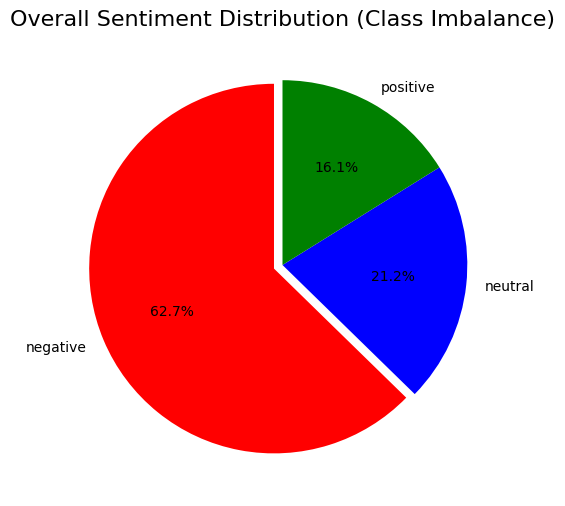

In [44]:
plt.figure(figsize=(8, 6))

data['sentiment'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%',   # Shows the percentage on the chart
    colors=['red', 'blue', 'green'], 
    explode=[0.05, 0, 0], # Pops out the first (negative) slice slightly for emphasis
    startangle=90
)
plt.title('Overall Sentiment Distribution (Class Imbalance)', fontsize=16)
plt.ylabel('') # Removes the default y-axis label to make it look cleaner
plt.show()

### Overall Sentiment Distribution (Class Imbalance)
This pie chart visualizes the baseline distribution of the target variable (`sentiment`) across the entire dataset.
*   **Severe Class Imbalance:** The dataset is heavily skewed toward negative sentiment, which accounts for nearly two-thirds (**62.7%**) of all customer interactions. 
*   **Minority Classes:** Neutral sentiment makes up 21.2%, while positive sentiment is the absolute minority at only **16.1%**.
*   **Machine Learning Implications:** This is a critical finding for the modeling phase. Because the data is so heavily imbalanced, a naive AI model could achieve 62% accuracy simply by guessing "negative" every single time. To prevent the model from becoming biased against the minority classes (positive/neutral), advanced techniques such as class-weighting, SMOTE (oversampling), or utilizing F1-scores rather than raw accuracy will be required during model training.

### Checking for tweet length distribution

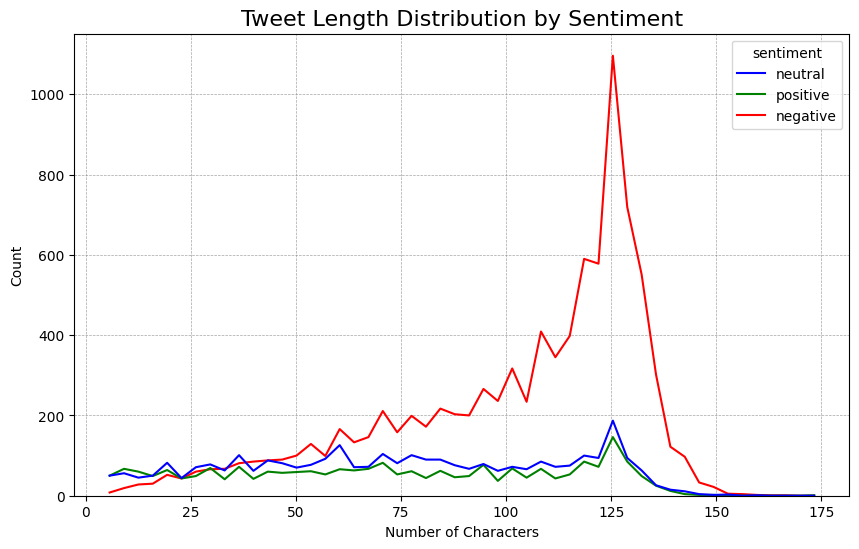

In [48]:

# Create a temporary column calculating the length of each tweet (number of characters)
data['tweet_length'] = data['feedback'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 6))

# Use histplot instead of kdeplot to avoid the cuDF GPU bug
sns.histplot(
    data=data, 
    x='tweet_length', 
    hue='sentiment', 
    palette={'negative':'red', 'neutral':'blue', 'positive':'green'}, 
    element='poly',   # This makes it draw smooth lines similar to a KDE plot!
    fill=False,
    bins=50           # Groups the character counts into 50 clean buckets
)

plt.title('Tweet Length Distribution by Sentiment', fontsize=16)
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


### Tweet Length Distribution by Sentiment
This line chart graphs the physical length (character count) of tweets, segmented by sentiment. It reveals one of the most fascinating behavioral insights in the dataset.
*   **The 140-Character Phenomenon:** There is a massive, towering spike of negative tweets (red line) specifically concentrated between the 120 and 140-character mark. Because this dataset originates from 2015, this directly correlates with Twitter's strict 140-character limit at the time. 
*   **Customer Psychology:** This visually proves that dissatisfied customers have so much to complain about that they consistently max out the entire character limit to articulate their grievances. 
*   **Concise Positivity:** Conversely, the distributions for positive (green) and neutral (blue) tweets are much flatter and consistently shorter, generally ranging between 10 and 100 characters. Happy customers leave short, concise "thank you" messages, while angry customers write essays.
*   **Predictive Power:** From an NLP standpoint, `tweet_length` is a highly predictive mathematical feature. If a string of text in this dataset approaches 140 characters, there is a very high statistical probability that it belongs to the negative class.

### Plotting word cloud

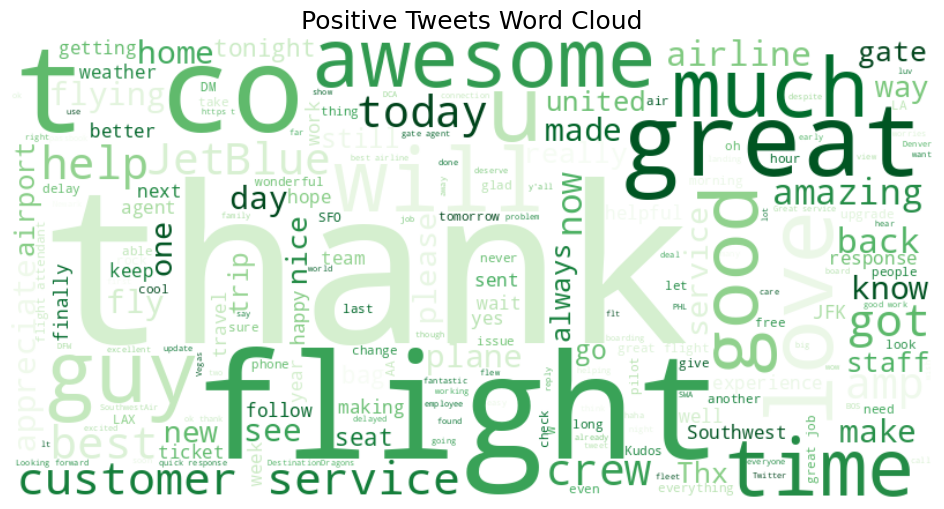

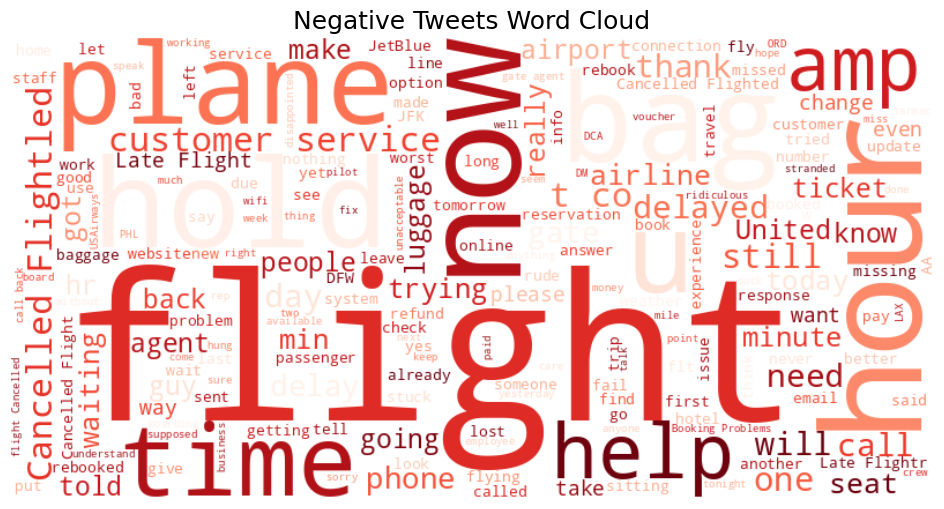

In [49]:
from wordcloud import WordCloud

# Group all text together based on sentiment
positive_text = " ".join(str(tweet) for tweet in data[data['sentiment'] == 'positive']['feedback'])
negative_text = " ".join(str(tweet) for tweet in data[data['sentiment'] == 'negative']['feedback'])

# Create WordCloud objects
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# Plot Positive WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off') # Hides the axis numbers
plt.title('Positive Tweets Word Cloud', fontsize=18)
plt.show()

# Plot Negative WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets Word Cloud', fontsize=18)
plt.show()


### Sentiment Word Clouds (Positive vs. Negative Lexicon)
Word clouds provide an intuitive visualization of the most statistically significant vocabulary used by customers based on their emotional state.
*   **The Anatomy of Positive Sentiment (Green):** The positive word cloud is heavily driven by expressions of gratitude and praise. Words like *"thank," "awesome," "great," "love,"* and *"best"* dominate the visual space. Interestingly, *"customer service"* and *"help"* also appear prominently here, indicating that when airline staff successfully resolve an issue, it generates incredibly strong brand loyalty.
*   **The Anatomy of Negative Sentiment (Red):** The negative word cloud exposes the root causes of customer frustration: operational failure and lost time. The most massive words are *"flight," "hour," "time," "now," "hold," "delayed,"* and *"Cancelled."* The heavy density of temporal words (*"hour," "time," "now," "waiting," "hold"*) mathematically proves that passengers are not just angry about the delay itself, but about the prolonged uncertainty and the time wasted trying to get a resolution.

### Top 10 Most Common Bigrams (2-Word Phrases)


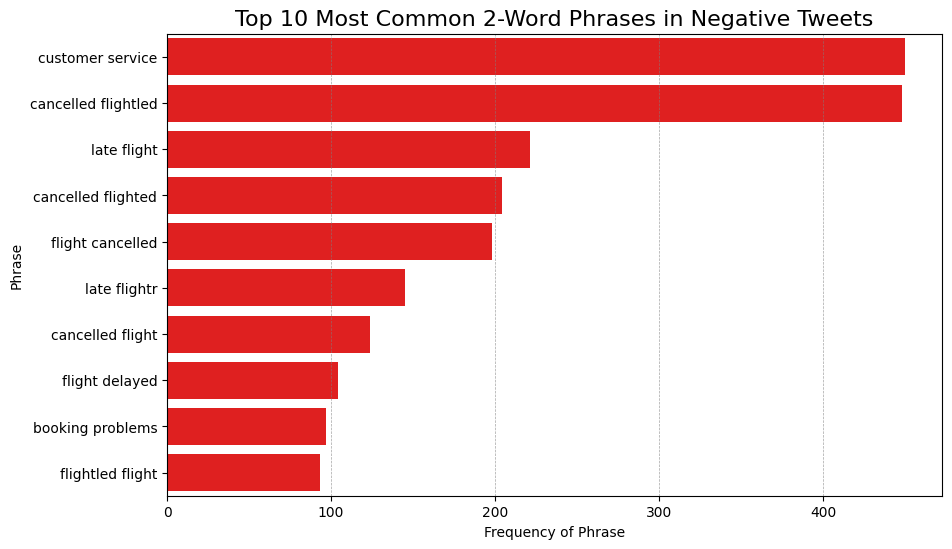

In [51]:
from sklearn.feature_extraction.text import CountVectorizer

# takes only the negative tweets and drop all missing values
neg_tweets = data[data['sentiment'] == 'negative']['feedback'].dropna()

# initializing CountVectorizer to find Bigrams (ngram_range=(2,2)) and remove 'stop_words'
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
X = vectorizer.fit_transform(neg_tweets)

# Convert to a DataFrame so we can plot it easily
bigrams_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
bigram_counts = bigrams_df.sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=bigram_counts.values, y=bigram_counts.index, color='red')

plt.title('Top 10 Most Common 2-Word Phrases in Negative Tweets', fontsize=16)
plt.xlabel('Frequency of Phrase')
plt.ylabel('Phrase')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


### Top 10 Most Common 2-Word Phrases (Bigrams) in Negative Tweets
While single words provide context, Bigrams (2-word phrases) reveal the exact focal points of customer anger.
*   **The Core Failure Point:** The phrase *"customer service"* is the absolute most frequent bigram in negative tweets. This is a profound business insight: **the physical delay or cancellation of a plane is only the *catalyst*. The actual driver of digital brand damage is the failure of the airline's customer service infrastructure** to support the passenger *after* the logistical failure occurs.
*   **Logistical Cascades:** The remainder of the top 10 list is entirely composed of logistical failures: variations of *"cancelled flight," "late flight," "flight delayed,"* and *"booking problems."* 
*   **NLP Data Artifacts (Misspellings):** The list contains several misspelled variations such as *"cancelled flightled," "cancelled flighted,"* and *"late flightr."* This is a classic NLP artifact demonstrating the raw, unedited nature of social media data—especially when typed by angry, stressed passengers on mobile devices. **Research Note:** From a machine learning perspective, this proves that the text preprocessing pipeline will require strict *Lemmatization* or *Stemming* to mathematically group these misspelled variations into a single root feature before training the model.